In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# XPS Data Overview

This file provides an Overview on the XPS data acquired for ILs on different supports (Au or Cu) and treated in different ways.

## Data import

The comments indicate which type of experiment was performed

In [2]:
data_xps = '../data/xps_raw/'

# pure Au foil
file_Au = data_xps + '20240228_Au_Folie.csv'
file_Au2 = '../data/xps_raw/2025-11-26_au_foil/2025-11-26_au-foil_survey.csv'

# as received IL (droplet in Au support)
file_Au_IL = data_xps + '20240228_Au_MPPipTFSIIol3_survey.csv'

# IL dried with a molecular sieve (droplet)
file_Au_MS = data_xps + '20240305_MPPipTFSIIol3MS4A_survey.csv'
file_Au_MS2 = data_xps + '20240220_Au_MPPipTFSI4AMSIol3_survey.csv'

# Na electrodeposition from an as received IL
file_Au_Na = data_xps + '20240621_Au_Nadep_from_MPPipTFSI_survey.csv'
file_Au_Na2 = '../data/xps_raw/2025-11-26_au-il_as_received/2025-11-26_au-il_as_received_survey.csv'

# Na electrodeposition from IL dried with a molecular sieve (MS)
file_Au_Na_MS = data_xps + '20240228_Au_Nadep_from_MPPipTFSI4AMSIol3_survey.csv'
file_Au_Na_MS2 = data_xps + '20240724_Au_Nadep_from_MPPipTFSI4AMSIol3_survey.csv'
## Na signals were lower in a second measurement on the same sample
# file_Au_Na3 = data_xps + '20240724_Au_Nadep_from_MPPipTFSI4AMSIol3_survey2.csv'
file_Au_Na_MS3 = '../data/xps_raw/2025-11-26_au-il_dired/2025-11-26_au-il_dried_survey.csv'

In [3]:
# create DataFrames
df_Au = pd.read_csv(file_Au, header=3)
df_Au2 = pd.read_csv(file_Au2, header=3)

df_Au_IL = pd.read_csv(file_Au_IL, header=3)

df_Au_MS = pd.read_csv(file_Au_MS, header=3)
df_Au_MS2 = pd.read_csv(file_Au_MS2, header=3)


df_Au_Na = pd.read_csv(file_Au_Na, header=3)
df_Au_Na2 = pd.read_csv(file_Au_Na2, header=3)

df_Au_Na_MS = pd.read_csv(file_Au_Na_MS, header=3)
df_Au_Na_MS2 = pd.read_csv(file_Au_Na_MS2, header=3)
df_Au_Na_MS3 = pd.read_csv(file_Au_Na_MS3, header=3)


# to some extend the files have different number of columns
print(df_Au_Na.head(3))
print(df_Au.head(3))

   BE_Sur1 1  CPS_Sur1 1  Background_Sur1 1
0     1399.0    112785.0           112785.0
1     1398.6    111762.0           111762.0
2     1398.2    112538.0           112538.0
   BE_Sur1 1  CPS_Sur1 1
0     1399.0    140106.0
1     1398.6    139147.0
2     1398.2    138447.0


## helper functions

In [4]:
def set_baseline(df, where=0):
    """removes the first data point from the dataframe to set
    that point as zero baseline for better comparison.
    It is specifically useful for peak regions."""
    df_ = df.reset_index(drop=True)
    columns = df_.columns
    for column in columns:
        if 'CPS' in column:
            cps_column = column
    df_['CPS BL'] = df_[cps_column] - df_[cps_column][where]
    return df_

def normalize_counts(df, max_counts):
    """normalize counts to maximum value of the Au 4f signal
    of the bare Au sample.
    Makes only sense if a Au peak is observed."""
    df_ = df.copy()
    columns = df_.columns
    for column in columns:
        if 'CPS' in column:
            cps_column = column
    df_counts = df_[df_['BE_Sur1 1'].between(60,100)][cps_column].max()
    print(df_counts)
    df_['CPS NORM'] = df_[cps_column] *  max_counts / df_counts
    return df_

## Survey spectra

### Pure Au

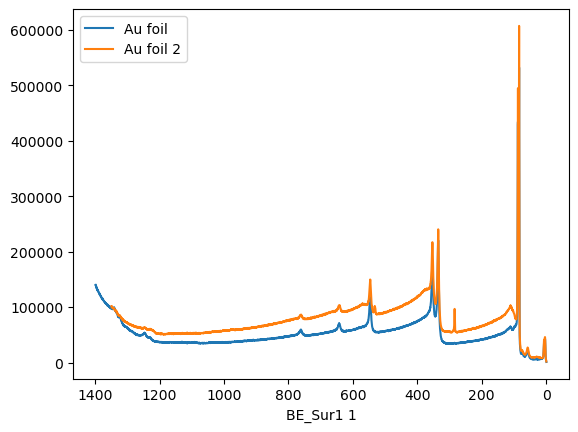

In [5]:
fig, ax = plt.subplots()

df_Au.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil 2')
ax.invert_xaxis()

In [6]:
max_counts_4f = df_Au2['CPS_Sur1 1'].max()
max_counts_4f

np.float64(607309.0)

### Exploring pure Au

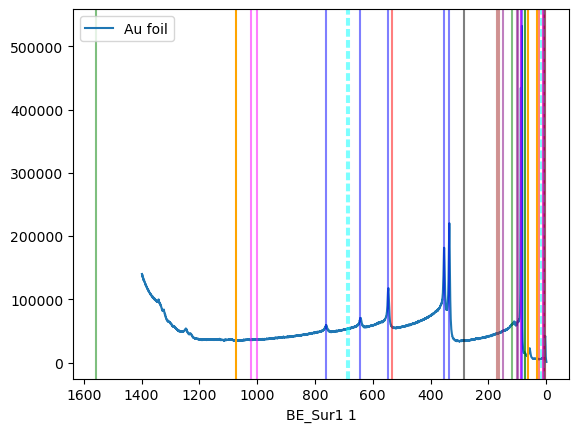

In [8]:
fig, ax = plt.subplots()

df_Au.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
ax.invert_xaxis()
Au = [762, 643, 546, 353, 335, 88, 84]

# Au peaks in red
for i in Au:    
    ax.axvline(i, color='blue', alpha=0.5)

# O peaks in blue
O = [532, 24, 7]
for i in O:
    ax.axvline(i, color='red', alpha=0.5)

# peaks in black
C = [284, 7]
for i in C:
    ax.axvline(i, color='black', alpha=0.5)

# # Al peaks in green
Al = [1559.6, 117.8, 72.95, 72.55]
for i in Al:
    ax.axvline(i, color='green', alpha=0.5)

# Si peaks in purple
Si = [149, 100, 99, 8, 3]
for i in Si:
    ax.axvline(i, color='purple', alpha=0.5)

# Na peaks in orange
Na = [1072, 63, 31]
for i in Na:
    ax.axvline(i, color='orange')

# F peaks in dsahed blue
F = [689, 684, 19, 7]
for i in F:
    ax.axvline(i, color='cyan', linestyle='dashed', alpha=0.5)

# S peaks in brown
S = [169, 163, 12, 3]
for i in S:
    ax.axvline(i, color='brown', alpha=0.5)

# Zn peaks in magenta
Zn= [1022, 999, 87, 10]
for i in Zn:
    ax.axvline(i, color='magenta', alpha=0.5)

# Ag= [719, 604, 573, 374, 368, 97, 64, 58]
# for i in Ag:
#     ax.axvline(i, color='green', alpha=0.5)

### Comparison of all surveys

Text(0.5, 1.0, 'XPS surveys of Au foil with IL')

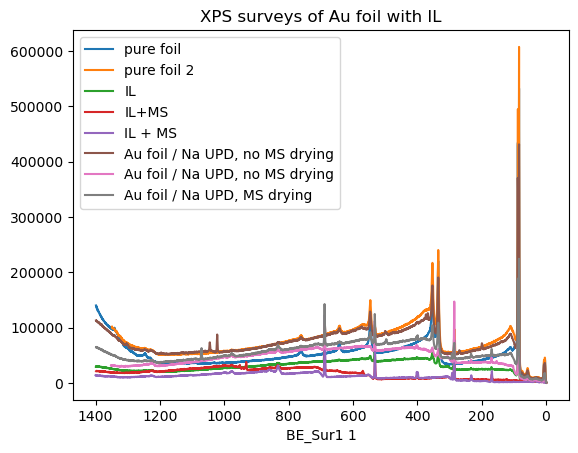

In [5]:
fig, ax = plt.subplots()

df_Au.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='pure foil')
df_Au2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='pure foil 2')

df_Au_IL.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='IL')

df_Au_MS.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='IL+MS')
df_Au_MS2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='IL + MS')


df_Au_Na.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS drying')
df_Au_Na2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS drying')

df_Au_Na_MS2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, MS drying')

ax.invert_xaxis()
ax.set_title('XPS surveys of Au foil with IL')


Compare MS dried ILs and no MS dried ILs

Text(0.5, 1.0, 'XPS surveys of Au foil with ILs dried with molecular sieves')

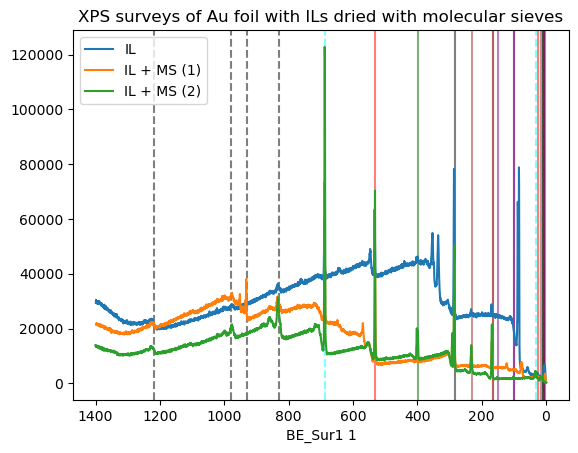

In [ ]:
fig, ax = plt.subplots()



# O peaks in blue
O = [532, 24, 7]
for i in O:
    ax.axvline(i, color='red', alpha=0.5)

# peaks in black
C = [284, 7]
for i in C:
    ax.axvline(i, color='black', alpha=0.5)

# F peaks in dsahed blue
F = [686, 31, 9]
for i in F:
    ax.axvline(i, color='cyan', linestyle='dashed', alpha=0.5)

# S peaks in brown
S = [229, 165, 164, 16, 8]
for i in S:
    ax.axvline(i, color='brown', alpha=0.5)

# # Zn peaks in magenta
# Zn= [11294. 1044,, 1021, 137, 87, 10]
# for i in Zn:
#     ax.axvline(i, color='magenta', alpha=0.5)

# # Na peaks in orange
# Na = [1072, 63, 31]
# for i in Na:
#     ax.axvline(i, color='orange')

# Si peaks in purple
Si = [149, 100, 99, 8, 3]
for i in Si:
    ax.axvline(i, color='purple', alpha=0.5)

# N peaks in dark green
N = [399, 9]
for i in N:
    ax.axvline(i, color='darkgreen', alpha=0.5)

# # Sn peaks in grey
# Sn = [885, 757, 715, 493, 485, 137, 84, 25, 24]
# for i in Sn:
#     ax.axvline(i, color='grey', alpha=0.5)

# pure Au foil
# df_Au.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='pure foil')
# df_Au2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='pure foil 2') # uncomment for second set
unknown = [1220, 980, 930, 830]
for i in unknown:
    ax.axvline(i, color='black', linestyle='dashed', alpha=0.5)

# not Sc
# 1200 are C Auger peaks
# 930+ are F Auger peaks
# 830+ are O Auger peaks

df_Au_IL.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='IL')

df_Au_MS.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='IL + MS (1)')
df_Au_MS2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='IL + MS (2)')

# df_Au_Na.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS drying')
# df_Au_Na2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS drying')
# df_Au_Na_MS2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, MS drying')



ax.invert_xaxis()
ax.set_title('XPS surveys of Au foil with ILs dried with molecular sieves')


We normalize all spectra to the pure Au signal for better comparison

607309.0
78832.4
7767.65


Text(0.5, 1.0, 'XPS surveys of Au foil with ILs dried with molecular sieves')

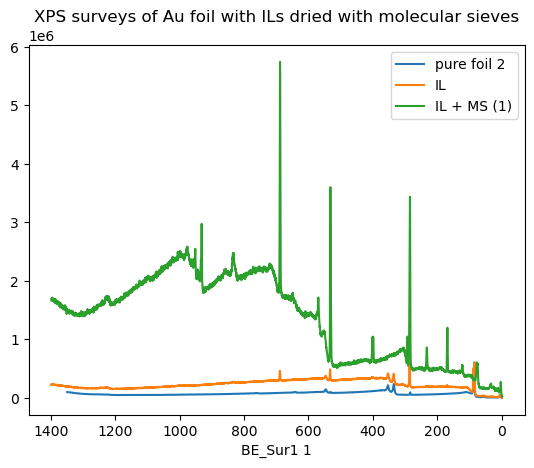

In [114]:
fig, ax = plt.subplots()

# df_Au.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='pure foil')
normalize_counts(df_Au2, max_counts_4f).plot('BE_Sur1 1', 'CPS NORM', ax=ax, label='pure foil 2') # uncomment for second set

normalize_counts(df_Au_IL, max_counts_4f).plot('BE_Sur1 1', 'CPS NORM', ax=ax, label='IL')

normalize_counts(df_Au_MS, max_counts_4f).plot('BE_Sur1 1', 'CPS NORM', ax=ax, label='IL + MS (1)')
# normalize_counts(df_Au_MS2, max_counts_4f).plot('BE_Sur1 1', 'CPS NORM', ax=ax, label='IL + MS (2)')

# df_Au_Na.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS drying')
# df_Au_Na2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS drying')
# df_Au_Na_MS2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, MS drying')

ax.invert_xaxis()
ax.set_title('XPS surveys of Au foil with ILs dried with molecular sieves')


Compare Na electrodeposition from pure and MS dried IL

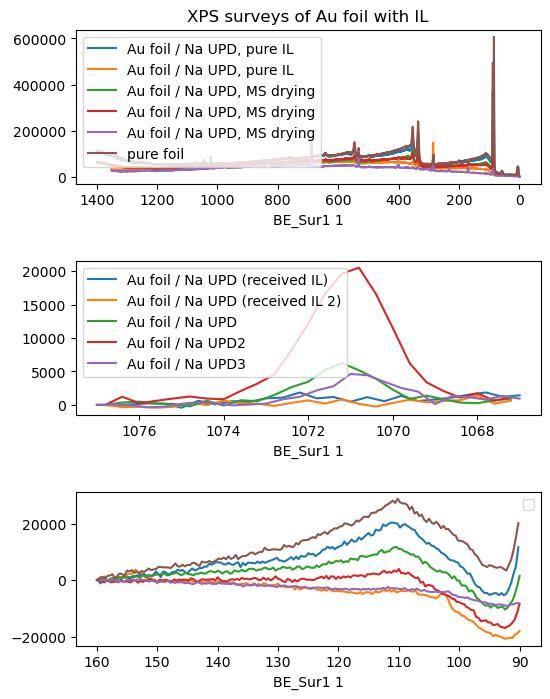

In [61]:
fig, ax = plt.subplots(3,1, sharex=False, figsize=(6,8))

ax, ax1, ax2 = ax


df_Au_Na.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, pure IL')
df_Au_Na2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, pure IL')

df_Au_Na_MS.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, MS drying')
df_Au_Na_MS2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, MS drying')
df_Au_Na_MS3.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, MS drying')

df_Au2.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='pure foil')


## Plot Na region
Na_limits =[1067, 1077]

# df_Au[df_Au['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax1, label='Au foil')
# df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax1, label='Au foil / IL')

set_baseline(df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Na_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax1, label='Au foil / Na UPD (received IL)')
set_baseline(df_Au_Na2[df_Au_Na2['BE_Sur1 1'].between(*Na_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax1, label='Au foil / Na UPD (received IL 2)')

set_baseline(df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Na_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax1, label='Au foil / Na UPD')
set_baseline(df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Na_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax1, label='Au foil / Na UPD2')
set_baseline(df_Au_Na_MS3[df_Au_Na_MS3['BE_Sur1 1'].between(*Na_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax1, label='Au foil / Na UPD3')

# df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax1, label='Au foil / IL+MS')
# df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax1, label='Au foil / IL+MS2')


## Plot Si region
Si_limits =[90, 160]#105]

## Use this to explore random other limits
# Si_limits =[400, 430]#105]


# df_Au[df_Au['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
# df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')


set_baseline(df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Si_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax2, label='Au foil / Na UPD, no MS')
set_baseline(df_Au_Na2[df_Au_Na2['BE_Sur1 1'].between(*Si_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax2, label='Au foil / Na UPD, no MS 2')

set_baseline(df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Si_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax2, label='Au foil / Na UPD 1')
set_baseline(df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Si_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax2, label='Au foil / Na UPD 2')
set_baseline(df_Au_Na_MS3[df_Au_Na_MS3['BE_Sur1 1'].between(*Si_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax2, label='Au foil / Na UPD 3')

set_baseline(df_Au2[df_Au2['BE_Sur1 1'].between(*Si_limits)]).plot('BE_Sur1 1', 'CPS BL', ax=ax2, label='Au foil')


# df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')
# df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL + MS')


ax.invert_xaxis()
ax1.invert_xaxis()
ax2.invert_xaxis()
ax2.legend('')
ax.set_title('XPS surveys of Au foil with IL')

plt.subplots_adjust(hspace=0.5)


For samples with a thick IL film, the Au signal is suppressed. In the case of the UPD experiments the IL was removed from the surface with acetone, leading to an increase in Au signal

## Magnifying the Au region

The Au 4d region

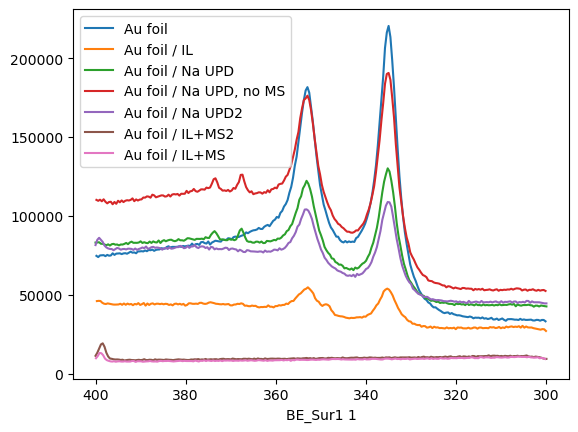

In [14]:
# Au 4d
Au_limits =[300, 400]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')
df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')
df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS')
ax.invert_xaxis()

The Au 4f region

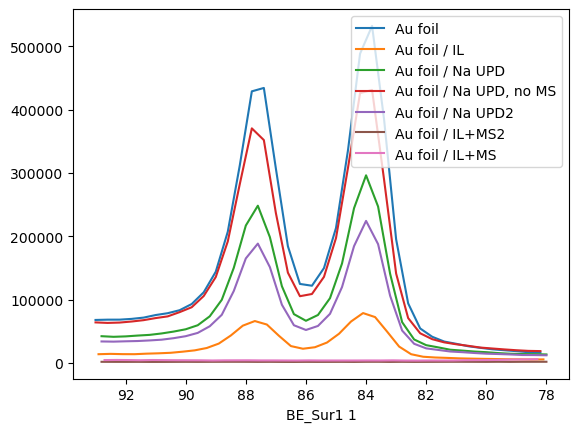

In [153]:
# Au 4f
Au_limits =[78, 93]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')
df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')
df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS')
ax.invert_xaxis()

The Au surface contains some Ag impurities.

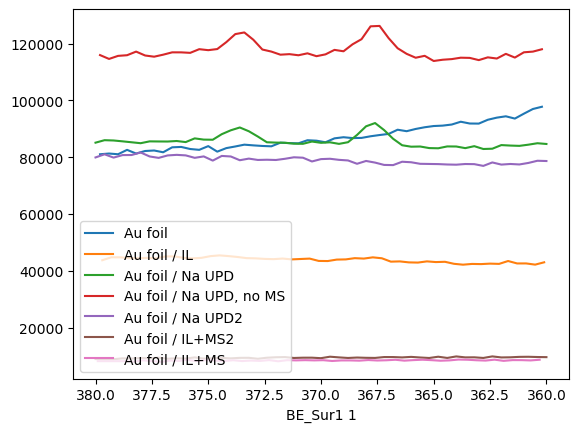

In [27]:

Au_limits =[360, 380]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')
df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')
df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Au_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS')
ax.invert_xaxis()

## Magnifying the Na region

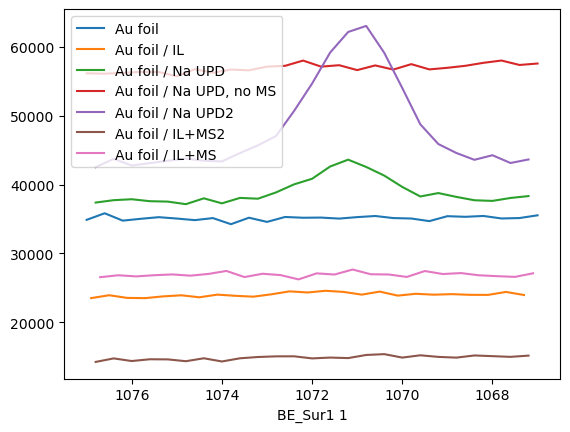

In [28]:
Na_limits =[1067, 1077]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')
df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')
df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS')
ax.invert_xaxis()

Na can also appear at 63 eV. Here we possibly see Li+, where Li should appear at 55 eV. However there is also a peak at around 74, hence the couple 57/74 is more liekly related to Au 5p.

Text(0.5, 1.0, 'Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

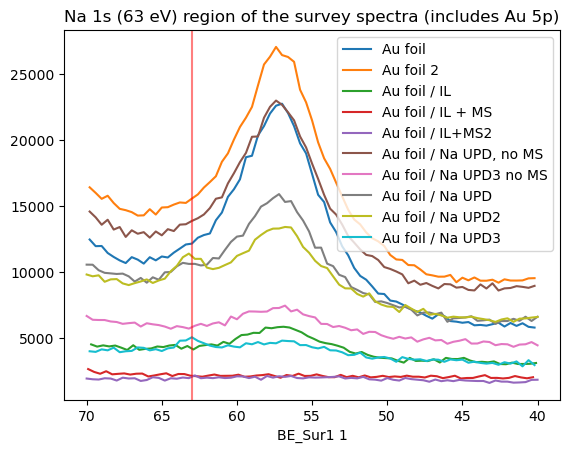

In [172]:
Na_limits =[40, 70]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au2[df_Au2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil 2')

df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')

df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL + MS')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')


df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na2[df_Au_Na2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD3 no MS')


df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_Na_MS3[df_Au_Na_MS3['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD3')

ax.invert_xaxis()


Na = [63]
# Ag = [58, 64, 97] # should appear as doublet on the first two lines 4p

for i in Na:
    ax.axvline(i, color='red', alpha=0.5)

ax.set_title('Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

Text(0.5, 1.0, 'Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

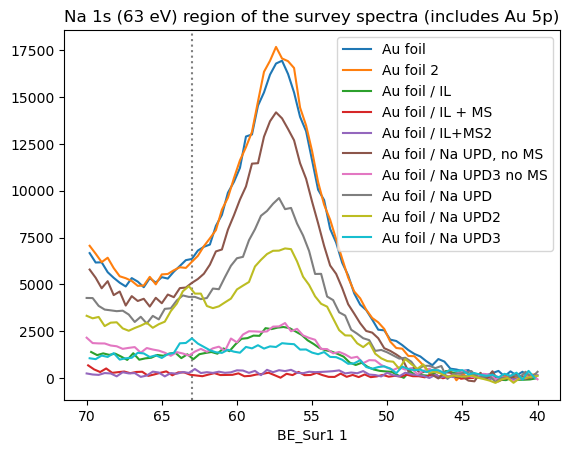

In [187]:
Na_limits =[40, 70]

fig, ax = plt.subplots()

# Sodium lines
Na = [63]
for i in Na:
    ax.axvline(i, color='black', linestyle=':', alpha=0.5)


set_baseline(df_Au[df_Au['BE_Sur1 1'].between(*Na_limits)],74).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil')
set_baseline(df_Au2[df_Au2['BE_Sur1 1'].between(*Na_limits)],70).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil 2')

set_baseline(df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Na_limits)],70).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / IL')

set_baseline(df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Na_limits)],70).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / IL + MS')
set_baseline(df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Na_limits)],70).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / IL+MS2')


set_baseline(df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Na_limits)],70).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD, no MS')
set_baseline(df_Au_Na2[df_Au_Na2['BE_Sur1 1'].between(*Na_limits)],70).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD3 no MS')


set_baseline(df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Na_limits)],70).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD')
set_baseline(df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Na_limits)],70).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD2')
set_baseline(df_Au_Na_MS3[df_Au_Na_MS3['BE_Sur1 1'].between(*Na_limits)],74).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD3')

ax.invert_xaxis()



ax.set_title('Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

## Magnifying the Si region

Si would appear at around 100 eV, for bare Si. SiO2 in turn would appear at around 104 eV, which is more likely. No clear Si peaks are apparent.

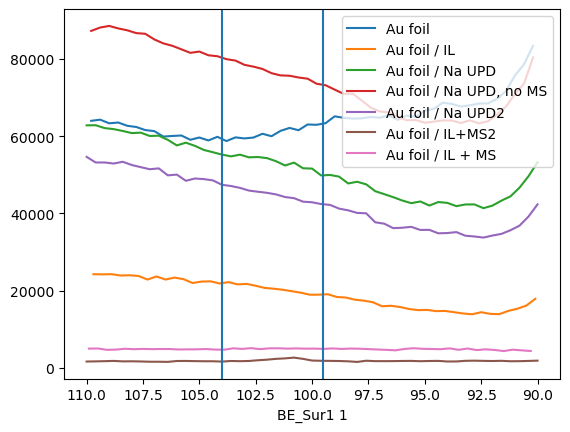

In [ ]:
Si_limits =[90, 110]#105]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')
df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')
df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL + MS')
ax.invert_xaxis()

# Si(0) peak
ax.axvline(99.5)

# Si(4+)
ax.axvline(104)

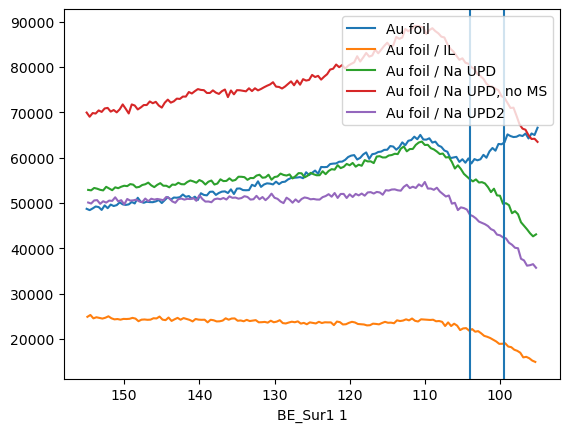

In [31]:
Si_limits =[145, 155]#105]
Si_limits =[95, 155]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')
df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
#df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')
ax.invert_xaxis()

# Si(0) peak
ax.axvline(99.5)

# Si(4+)
ax.axvline(104)

Text(0.5, 1.0, 'Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

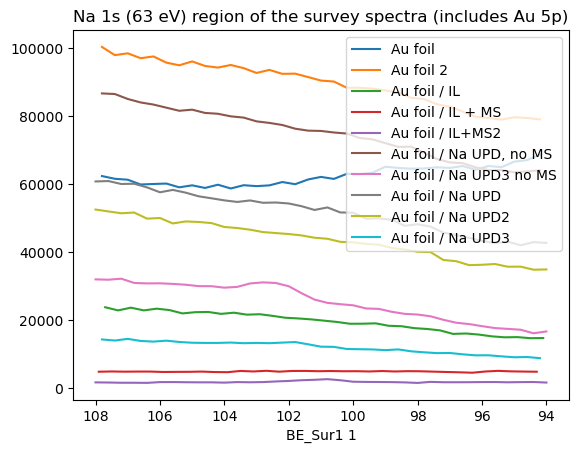

In [199]:
Na_limits =[94, 108]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au2[df_Au2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil 2')

df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')

df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL + MS')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')


df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na2[df_Au_Na2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD3 no MS')


df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_Na_MS3[df_Au_Na_MS3['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD3')

ax.invert_xaxis()


# Na = [63]
# # Ag = [58, 64, 97] # should appear as doublet on the first two lines 4p

# for i in Na:
#     ax.axvline(i, color='red', alpha=0.5)

ax.set_title('Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

Text(0.5, 1.0, 'Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

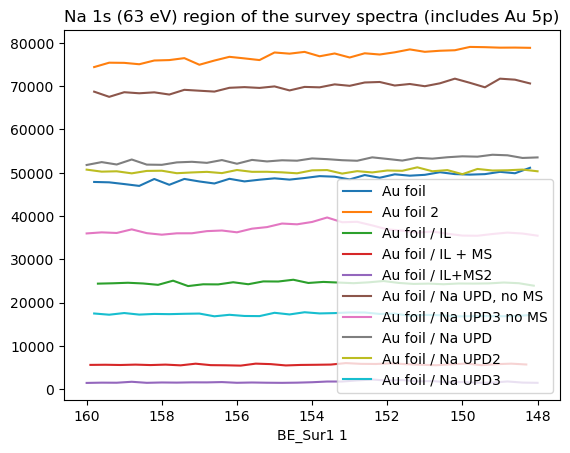

In [201]:
Na_limits =[148, 160]

fig, ax = plt.subplots()
df_Au[df_Au['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
df_Au2[df_Au2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil 2')

df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')

df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL + MS')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')


df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
df_Au_Na2[df_Au_Na2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD3 no MS')


df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_Na_MS3[df_Au_Na_MS3['BE_Sur1 1'].between(*Na_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD3')

ax.invert_xaxis()


# Na = [63]
# # Ag = [58, 64, 97] # should appear as doublet on the first two lines 4p

# for i in Na:
#     ax.axvline(i, color='red', alpha=0.5)

ax.set_title('Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

Text(0.5, 1.0, 'Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

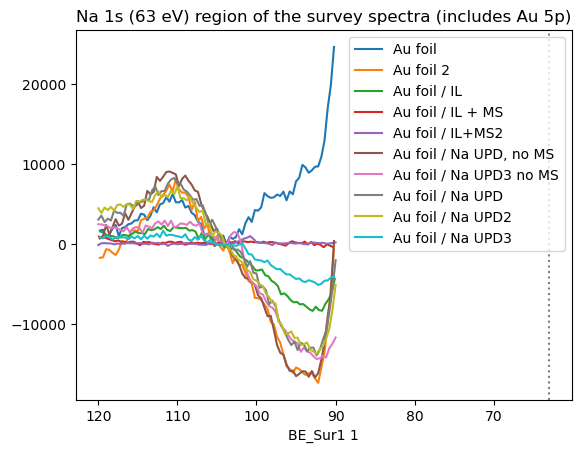

In [197]:
Na_limits =[90, 120]

baseline_point = 40

fig, ax = plt.subplots()

# Sodium lines
Na = [63]
for i in Na:
    ax.axvline(i, color='black', linestyle=':', alpha=0.5)


set_baseline(df_Au[df_Au['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil')
set_baseline(df_Au2[df_Au2['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil 2')

set_baseline(df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / IL')

set_baseline(df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / IL + MS')
set_baseline(df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / IL+MS2')


set_baseline(df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD, no MS')
set_baseline(df_Au_Na2[df_Au_Na2['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD3 no MS')


set_baseline(df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD')
set_baseline(df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD2')
set_baseline(df_Au_Na_MS3[df_Au_Na_MS3['BE_Sur1 1'].between(*Na_limits)], baseline_point).plot('BE_Sur1 1', 'CPS BL', ax=ax, label='Au foil / Na UPD3')

ax.invert_xaxis()



ax.set_title('Na 1s (63 eV) region of the survey spectra (includes Au 5p)')

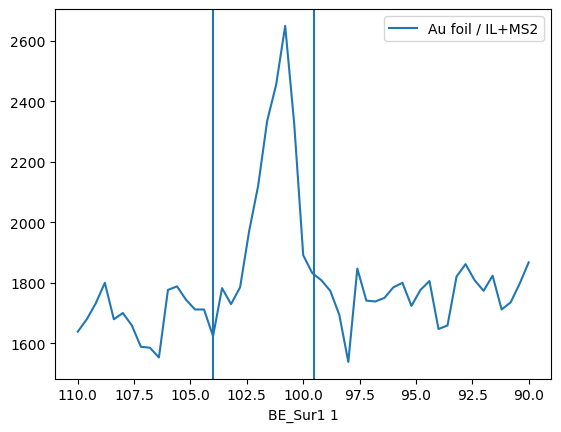

In [32]:
Si_limits =[90, 110]#105]

fig, ax = plt.subplots()
# df_Au[df_Au['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil')
# df_Au_IL[df_Au_IL['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL')
# df_Au_Na_MS[df_Au_Na_MS['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD')
# df_Au_Na[df_Au_Na['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD, no MS')
# df_Au_Na_MS2[df_Au_Na_MS2['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / Na UPD2')
df_Au_MS2[df_Au_MS2['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL+MS2')
# df_Au_MS[df_Au_MS['BE_Sur1 1'].between(*Si_limits)].plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil / IL + MS')
ax.invert_xaxis()

# Si(0) peak
ax.axvline(99.5)

# Si(4+)
ax.axvline(104)

### plotting on a log scale

trying to find additional features

(30000.0, 500000.0)

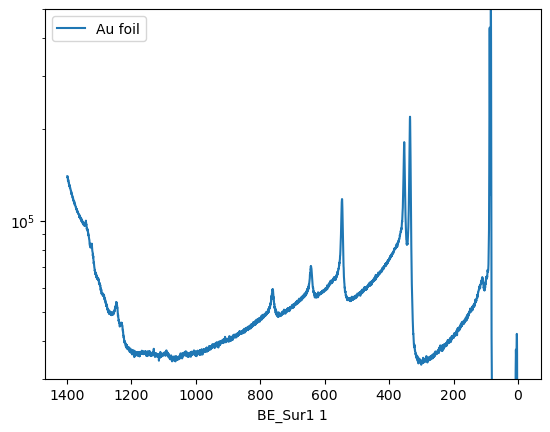

In [34]:
fig, ax = plt.subplots()

df_Au.plot('BE_Sur1 1', 'CPS_Sur1 1', ax=ax, label='Au foil',logy=True)
ax.invert_xaxis()
ax.set_ylim(3E4,5E5)

## Detail XP spectra

### Na (Sodium)

In [191]:
Na_files = ['20240220_Au_MPPipTFSI4AMSIol3_Na_1s.csv',
            '20240228_Au_MPPipTFSIIol3_Na_1s.csv',
            '20240305_MPPipTFSIIol3_Na_1s.csv',
            '20240305_MPPipTFSIIol3MS4A_Na_1s.csv',
            '20240621_Au_Nadep_from_MPPipTFSI_Na_1s.csv',
            '20240228_Au_Nadep_from_MPPipTFSI4AMSIol3_Na_1s.csv',
            '20240724_Au_Nadep_from_MPPipTFSI4AMSIol3_Na_1s.csv',
            '/2025-11-26_au-il_dired/2025-11-26_au-il_dried_Na_1s.csv'
]

df_Na = [pd.read_csv(data_xps + file, header=3) for file in Na_files]

Overview of all detail spectra, where Na is clearly seen after treating it with the molecular sieve and performing Na electrodeposition.

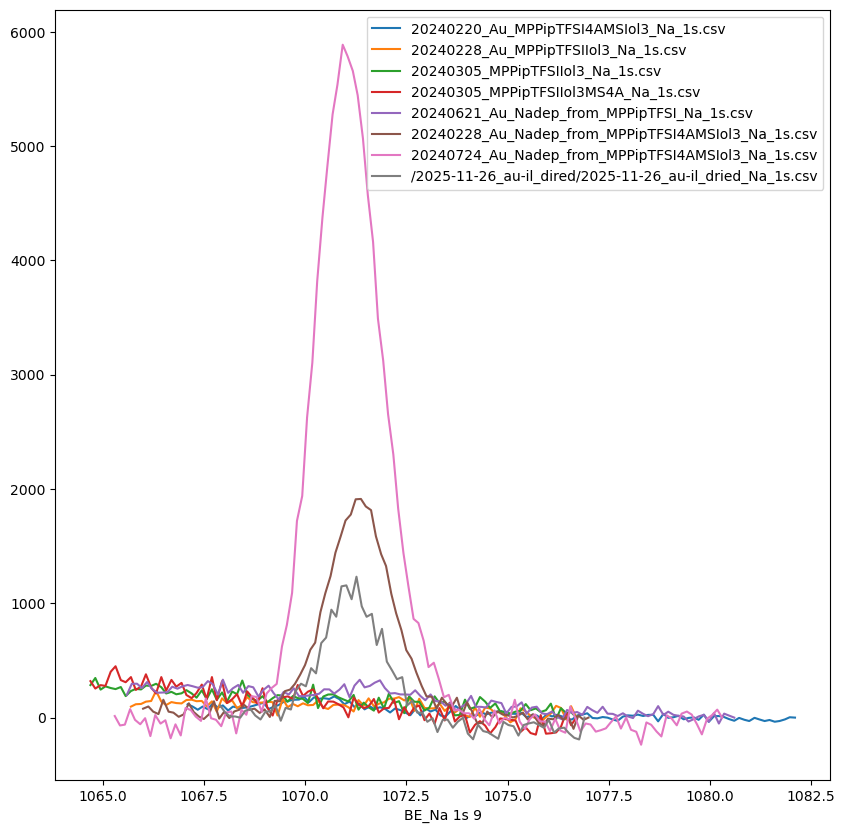

In [192]:
fig, ax = plt.subplots(figsize=(10,10))
for idx, df in enumerate(df_Na):
    energy = [colname for colname in df.columns if 'BE_Na 1s' in colname][0]
    column = [colname for colname in df.columns if 'CPS_Na 1s' in colname][0]
    set_baseline(df).plot(energy, 'CPS BL', ax=ax, label=Na_files[idx])
# ax.set_ylim(3000, 18000)

In the following image we see Na after deposition from the pure IL.

A bit of Na is seen in this specific case, which is probably caused by the Na being natively present in the pure IL (see below).

Text(0.5, 1.0, '20240621_Au_Nadep_from_MPPipTFSI_Na_1s.csv')

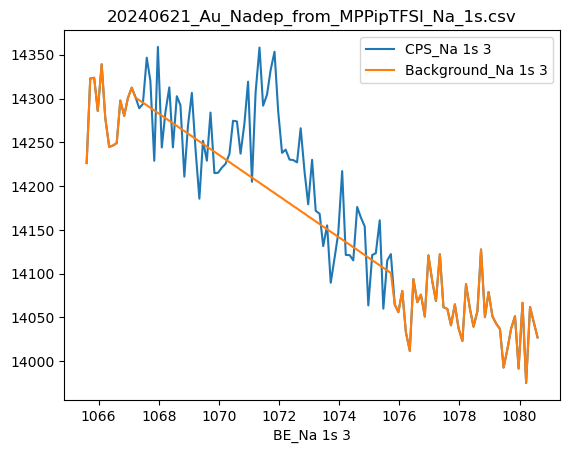

In [37]:
file = '20240621_Au_Nadep_from_MPPipTFSI_Na_1s.csv'
fig, ax = plt.subplots(1,1)
df = pd.read_csv(data_xps + file,header=3)
df.plot('BE_Na 1s 3','CPS_Na 1s 3' , ax=ax)
df.plot('BE_Na 1s 3','Background_Na 1s 3' , ax=ax)
plt.title(file)

No Na is seen in the following pure IL.

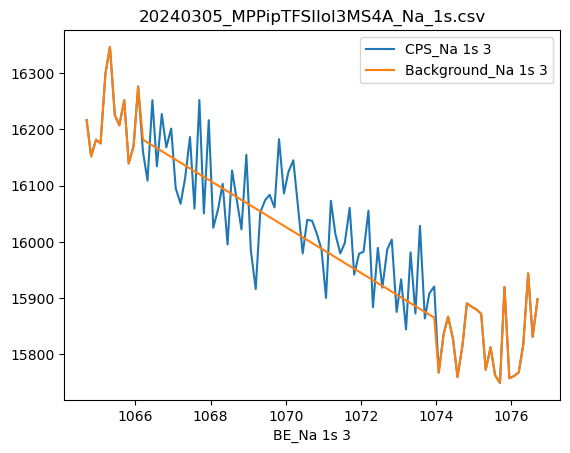

In [38]:
file = '20240305_MPPipTFSIIol3MS4A_Na_1s.csv'
def Na_plot(file):
    fig, ax = plt.subplots(1,1)
    df = pd.read_csv(data_xps + file,header=3)
    df.plot('BE_Na 1s 3','CPS_Na 1s 3' , ax=ax)
    df.plot('BE_Na 1s 3','Background_Na 1s 3' , ax=ax)
    plt.title(file)
Na_plot(file)

Here we see the Na in the IL after treating its with an MS.

Text(0.5, 1.0, '20240220_Au_MPPipTFSI4AMSIol3_Na_1s.csv')

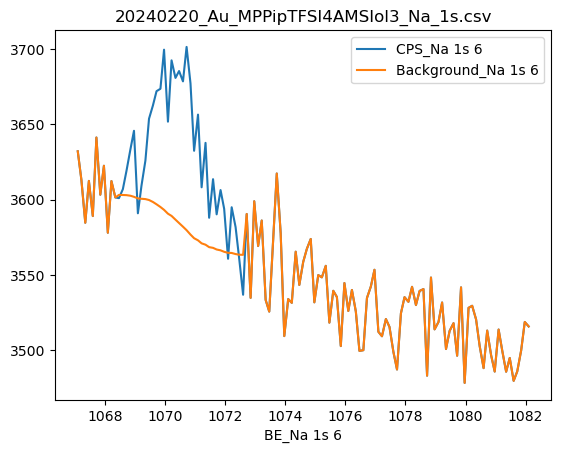

In [39]:
file = '20240220_Au_MPPipTFSI4AMSIol3_Na_1s.csv'
fig, ax = plt.subplots(1,1)
df = pd.read_csv(data_xps + file,header=3)
df.plot('BE_Na 1s 6','CPS_Na 1s 6' , ax=ax)
df.plot('BE_Na 1s 6','Background_Na 1s 6' , ax=ax)
plt.title(file)

Another example of the pure IL, with a tiny amount of Na

Text(0.5, 1.0, '20240228_Au_MPPipTFSIIol3_Na_1s.csv')

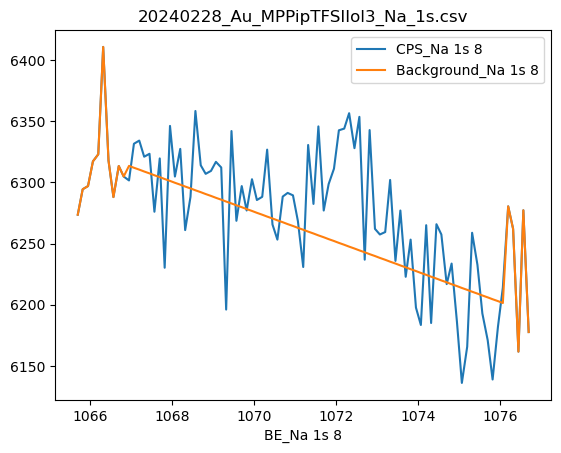

In [40]:
file = '20240228_Au_MPPipTFSIIol3_Na_1s.csv'
fig, ax = plt.subplots(1,1)
df = pd.read_csv(data_xps + file,header=3)
df.plot('BE_Na 1s 8','CPS_Na 1s 8' , ax=ax)
df.plot('BE_Na 1s 8','Background_Na 1s 8' , ax=ax)
plt.title(file)

A clear Na peak, when the IL is treated with a molecular sieve and Na is electrodeposited, as shown in the following two examples

Text(0.5, 1.0, '20240724_Au_Nadep_from_MPPipTFSI4AMSIol3_Na_1s.csv')

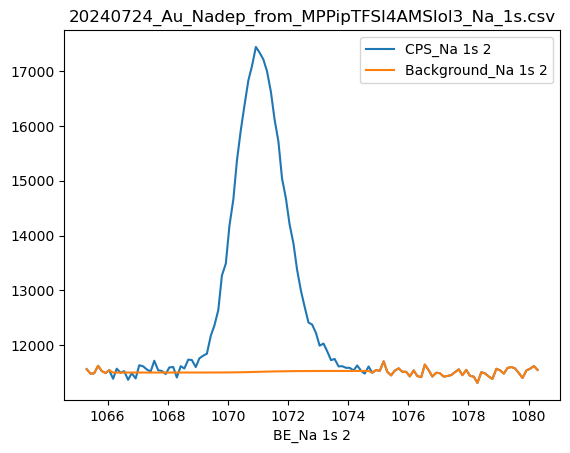

In [41]:
file = '20240724_Au_Nadep_from_MPPipTFSI4AMSIol3_Na_1s.csv'
fig, ax = plt.subplots(1,1)
df = pd.read_csv(data_xps + file,header=3)
df.plot('BE_Na 1s 2','CPS_Na 1s 2' , ax=ax)
df.plot('BE_Na 1s 2','Background_Na 1s 2' , ax=ax)
plt.title(file)

Text(0.5, 1.0, '20240228_Au_Nadep_from_MPPipTFSI4AMSIol3_Na_1s.csv')

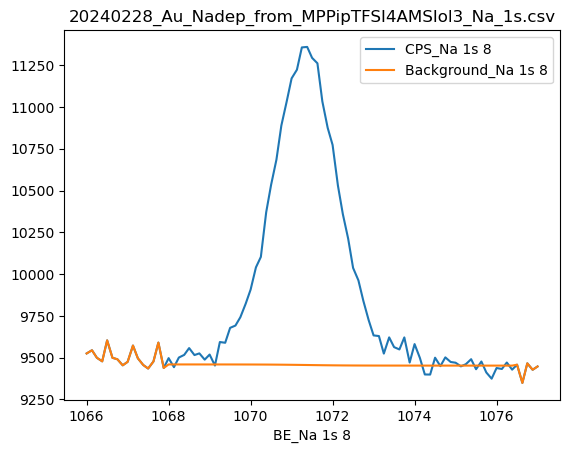

In [42]:
file = '20240228_Au_Nadep_from_MPPipTFSI4AMSIol3_Na_1s.csv'
fig, ax = plt.subplots(1,1)
df = pd.read_csv(data_xps + file,header=3)
df.plot('BE_Na 1s 8','CPS_Na 1s 8' , ax=ax)
df.plot('BE_Na 1s 8','Background_Na 1s 8' , ax=ax)
plt.title(file)

In [43]:
df.head()

,BE_Na 1s 8,CPS_Na 1s 8,Na 1s_1_Na 1s 8,Background_Na 1s 8,Envelope_Na 1s 8
0,1077.00,9446.6,9448.63,9446.6,9448.63
1,1076.88,9427.0,9429.18,9427.0,9429.18
2,1076.75,9465.4,9467.75,9465.4,9467.75
3,1076.63,9348.2,9350.73,9348.2,9350.73
4,1076.50,9457.4,9460.14,9457.4,9460.14


### Si (Silicon)

In [53]:
Si_2s_files = [
            '20240621_Au_Nadep_from_MPPipTFSI_Si_2s.csv',
            '2025-11-26_au-il_as_received/2025-11-26_au-il_as_received_Si-2s.csv'
]

# Ohne Molsieb: 20240305_MPPipTFSIIol3_Si_2p.csv
# Molsieb: 20240220_Au_MPPipTFSI4AMSIol3_Si_2p.csv

Si_2p_files = [
            '20240305_MPPipTFSIIol3_Si_2p.csv',
            '20240305_MPPipTFSIIol3MS4A_Si_2p.csv',
             '20240220_Au_MPPipTFSI4AMSIol3_Si_2p.csv',
]

df_Si_2s = [pd.read_csv(data_xps + file, header=3) for file in Si_2s_files]
df_Si_2p = [pd.read_csv(data_xps + file, header=3) for file in Si_2p_files]
len(df_Si_2p)

3

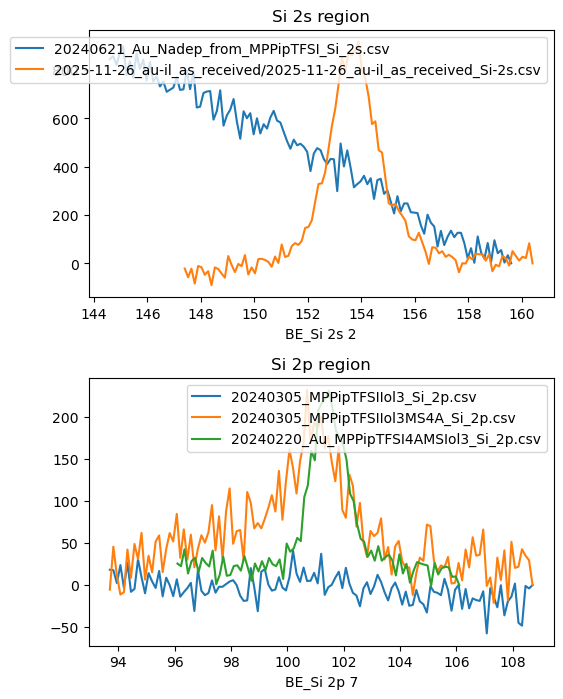

In [56]:
fig, ax = plt.subplots(2,1, figsize=(6,8))

ax, ax1 = ax

for idx, df in enumerate(df_Si_2s):
    energy = [colname for colname in df.columns if 'BE_Si 2s' in colname][0]
    column = [colname for colname in df.columns if 'CPS_Si 2s' in colname][0]
    set_baseline(df).plot(energy, 'CPS BL', ax=ax, label=Si_2s_files[idx])

ax.set_title('Si 2s region')

for idx, df in enumerate(df_Si_2p):
    energy = [colname for colname in df.columns if 'BE_Si 2p' in colname][0]
    column = [colname for colname in df.columns if 'CPS_Si 2p' in colname][0]
    set_baseline(df).plot(energy, 'CPS BL', ax=ax1, label=Si_2p_files[idx])

ax1.set_title('Si 2p region')

plt.subplots_adjust(hspace=0.3)


Text(0.5, 1.0, 'Si 2p region')

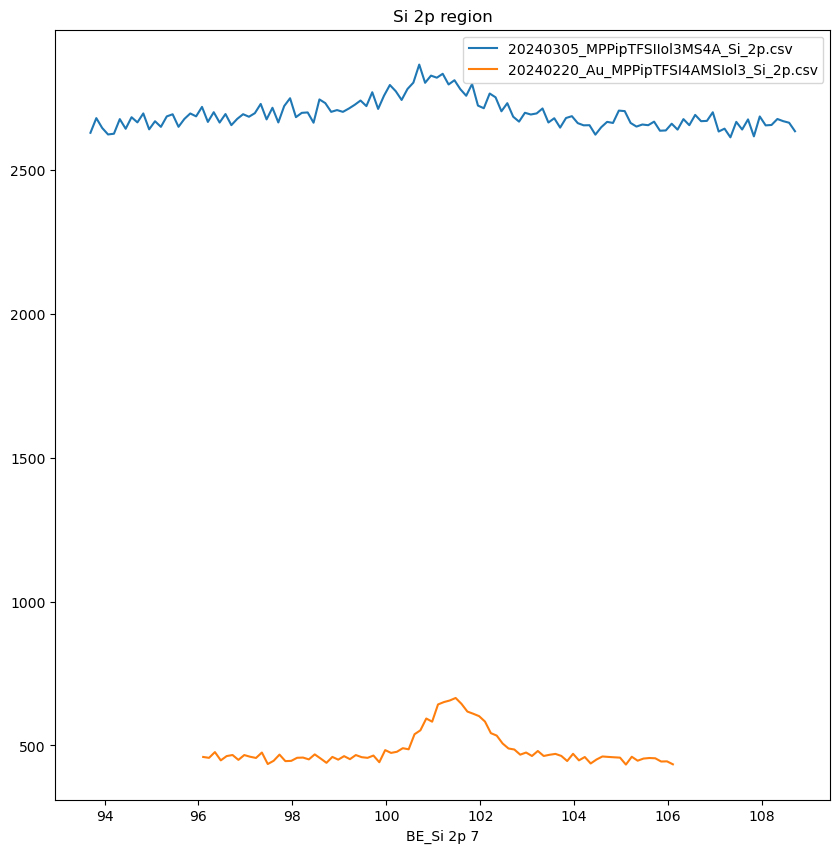

In [40]:
fig, ax = plt.subplots(figsize=(10,10))
for idx, df in enumerate(df_Si_2p):
    energy = [colname for colname in df.columns if 'BE_Si 2p' in colname][0]
    column = [colname for colname in df.columns if 'CPS_Si 2p' in colname][0]
    df.plot(energy, column, ax=ax, label=Si_2p_files[idx])
# ax.set_ylim(3000, 18000)
ax.set_title('Si 2p region')